In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pickle


In [3]:
import pandas as pd 
df=pd.read_csv(r"D:\Human Development Index\Dataset\HDI.csv")
df.head(5)
df.info()
df.describe()
df.isnull().sum()
df.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Columns: 880 entries, ISO3 to Material footprint per capita (tonnes) (2021)
dtypes: float64(876), str(4)
memory usage: 1.3 MB


['ISO3',
 'Country',
 'Human Development Groups',
 'UNDP Developing Regions',
 'HDI Rank (2021)',
 'Human Development Index (1990)',
 'Human Development Index (1991)',
 'Human Development Index (1992)',
 'Human Development Index (1993)',
 'Human Development Index (1994)',
 'Human Development Index (1995)',
 'Human Development Index (1996)',
 'Human Development Index (1997)',
 'Human Development Index (1998)',
 'Human Development Index (1999)',
 'Human Development Index (2000)',
 'Human Development Index (2001)',
 'Human Development Index (2002)',
 'Human Development Index (2003)',
 'Human Development Index (2004)',
 'Human Development Index (2005)',
 'Human Development Index (2006)',
 'Human Development Index (2007)',
 'Human Development Index (2008)',
 'Human Development Index (2009)',
 'Human Development Index (2010)',
 'Human Development Index (2011)',
 'Human Development Index (2012)',
 'Human Development Index (2013)',
 'Human Development Index (2014)',
 'Human Development Index (

In [4]:
with open("columns.txt", "w", encoding="utf-8") as f:
    for col in df.columns:
        f.write(col + "\n")

print("Column names saved successfully.")

Column names saved successfully.


In [5]:
data1 = df.head(20)
data1["Country"].unique()

<StringArray>
[           'Afghanistan',                 'Angola',                'Albania',
                'Andorra',   'United Arab Emirates',              'Argentina',
                'Armenia',    'Antigua and Barbuda',              'Australia',
                'Austria',             'Azerbaijan',                'Burundi',
                'Belgium',                  'Benin',           'Burkina Faso',
             'Bangladesh',               'Bulgaria',                'Bahrain',
                'Bahamas', 'Bosnia and Herzegovina']
Length: 20, dtype: str

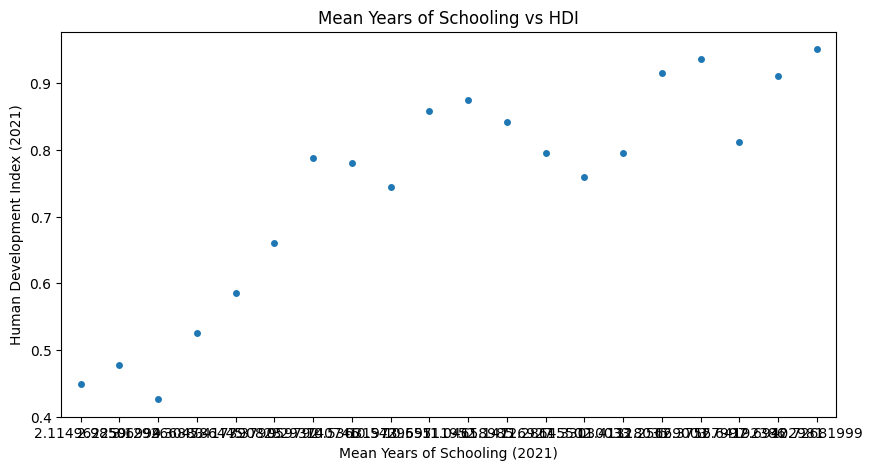

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.stripplot(
    x="Mean Years of Schooling (2021)",
    y="Human Development Index (2021)",
    data=data1
)

plt.title("Mean Years of Schooling vs HDI")
plt.xlabel("Mean Years of Schooling (2021)")
plt.ylabel("Human Development Index (2021)")

plt.show()

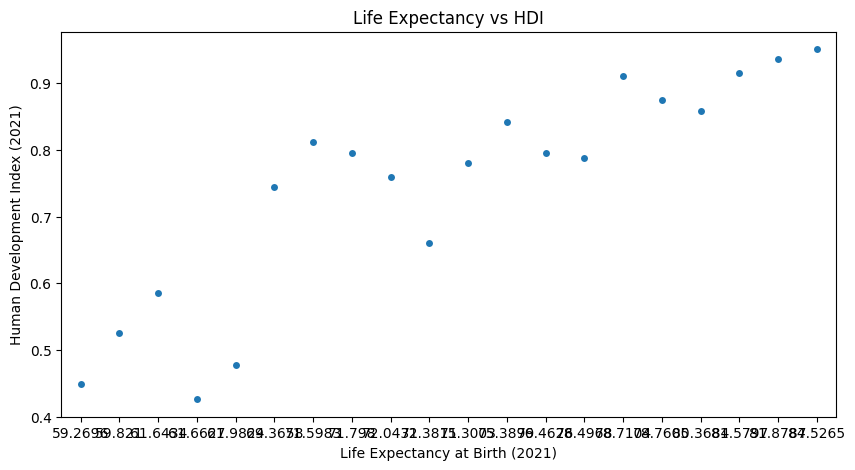

In [7]:
plt.figure(figsize=(10,5))

sns.stripplot(
    x="Life Expectancy at Birth (2021)",
    y="Human Development Index (2021)",
    data=data1
)

plt.title("Life Expectancy vs HDI")
plt.xlabel("Life Expectancy at Birth (2021)")
plt.ylabel("Human Development Index (2021)")

plt.show()

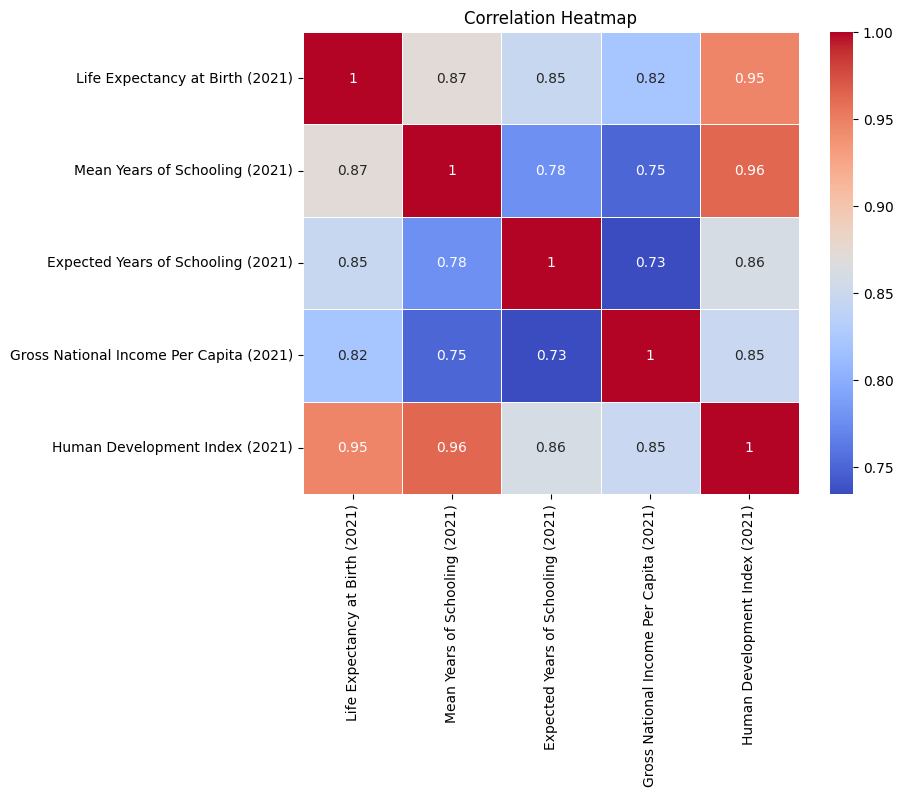

In [8]:
corr = data1[
[
"Life Expectancy at Birth (2021)",
"Mean Years of Schooling (2021)",
"Expected Years of Schooling (2021)",
"Gross National Income Per Capita (2021)",
"Human Development Index (2021)"
]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

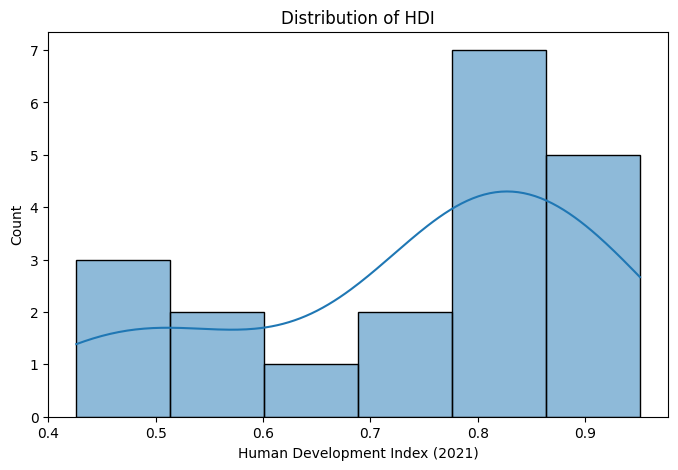

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    data1["Human Development Index (2021)"],
    kde=True
)

plt.title("Distribution of HDI")

plt.show()

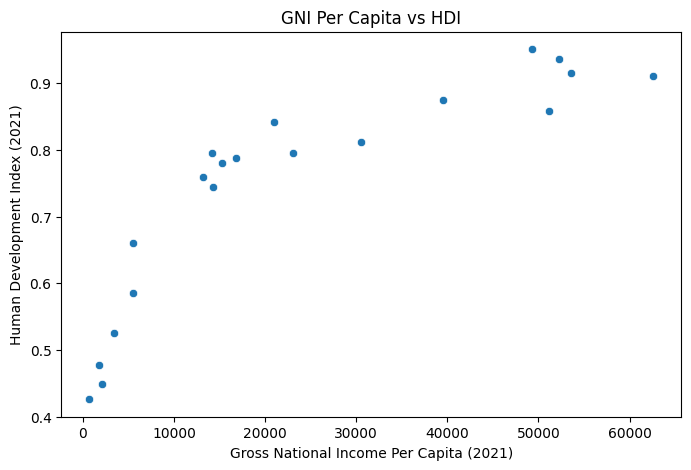

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Gross National Income Per Capita (2021)",
    y="Human Development Index (2021)",
    data=data1
)

plt.title("GNI Per Capita vs HDI")

plt.show()

In [11]:
X = df[
[
    "Country",
    "Life Expectancy at Birth (2021)",
    "Expected Years of Schooling (2021)",
    "Mean Years of Schooling (2021)",
    "Gross National Income Per Capita (2021)"
]
]
Y = df["Human Development Index (2021)"]
X.head()
Y.head()

0    0.478
1    0.586
2    0.796
3    0.858
4    0.911
Name: Human Development Index (2021), dtype: float64

In [12]:
X.isnull().sum()

Country                                    0
Life Expectancy at Birth (2021)            0
Expected Years of Schooling (2021)         2
Mean Years of Schooling (2021)             4
Gross National Income Per Capita (2021)    2
dtype: int64

In [13]:
numeric_cols = [
    "Life Expectancy at Birth (2021)",
    "Expected Years of Schooling (2021)",
    "Mean Years of Schooling (2021)",
    "Gross National Income Per Capita (2021)"
]

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].mean())

In [14]:
X.isnull().sum()

Country                                    0
Life Expectancy at Birth (2021)            0
Expected Years of Schooling (2021)         0
Mean Years of Schooling (2021)             0
Gross National Income Per Capita (2021)    0
dtype: int64

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X["Country"] = le.fit_transform(X["Country"])

In [16]:
X.head()


,Country,Life Expectancy at Birth (2021),Expected Years of Schooling (2021),Mean Years of Schooling (2021),Gross National Income Per Capita (2021)
0,0,61.9824,10.263844,2.985070,1824.190915
1,4,61.6434,12.172100,5.417391,5465.617791
2,1,76.4626,14.448000,11.286455,14131.110390
3,3,80.3684,13.300239,10.555120,51166.626610
4,184,78.7104,15.717690,12.694030,62573.591810


In [17]:
X.dtypes

Country                                      int64
Life Expectancy at Birth (2021)            float64
Expected Years of Schooling (2021)         float64
Mean Years of Schooling (2021)             float64
Gross National Income Per Capita (2021)    float64
dtype: object

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.25,
    random_state=0
)

In [19]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (146, 5)
X_test shape: (49, 5)
Y_train shape: (146,)
Y_test shape: (49,)


In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
model = LinearRegression()

In [22]:
Y.isnull().sum()

np.int64(4)

In [23]:
data = df[[
    "Country",
    "Life Expectancy at Birth (2021)",
    "Expected Years of Schooling (2021)",
    "Mean Years of Schooling (2021)",
    "Gross National Income Per Capita (2021)",
    "Human Development Index (2021)"
]].dropna()

In [24]:
X = data[[
    "Country",
    "Life Expectancy at Birth (2021)",
    "Expected Years of Schooling (2021)",
    "Mean Years of Schooling (2021)",
    "Gross National Income Per Capita (2021)"
]]

Y = data["Human Development Index (2021)"]

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X["Country"] = le.fit_transform(X["Country"])

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.25,
    random_state=0
)

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(Y_test, y_pred))

R2 Score: 0.9744940383774384


In [30]:
print(Y_test.values)
print(y_pred)

[0.501 0.858 0.597 0.607 0.615 0.714 0.812 0.4   0.821 0.788 0.842 0.739
 0.618 0.745 0.758 0.477 0.752 0.483 0.767 0.558 0.94  0.534 0.762 0.727
 0.745 0.675 0.632 0.706 0.713 0.55  0.911 0.498 0.925 0.942 0.509 0.666
 0.525 0.876 0.639 0.951 0.77  0.575 0.692 0.585 0.641 0.747 0.79  0.962]
[0.54179401 0.85277327 0.55616618 0.57642938 0.57320116 0.66452657
 0.79284901 0.42392813 0.79609138 0.78447843 0.84976367 0.73547386
 0.62543007 0.73226493 0.73156185 0.49190761 0.73804109 0.48971931
 0.77019825 0.54427382 0.96356485 0.55301798 0.75905372 0.73995197
 0.77899201 0.66332008 0.62645102 0.67937593 0.69425542 0.51479945
 0.89805927 0.50705398 0.92487743 0.95299477 0.47854123 0.64467692
 0.53742392 0.87241849 0.65529247 1.00688247 0.75530956 0.55965414
 0.73625788 0.58408609 0.63133778 0.7312846  0.80437806 0.96992301]


In [31]:
import pickle

pickle.dump(model, open("../Flask/HDI.pkl", "wb"))